In [3]:
import pandas as pd

df = pd.DataFrame({
    'temperature': [10, 7, 4, 0],
    'sales': [30, 50, 60, 80]
})

df

,temperature,sales
0,10,30
1,7,50
2,4,60
3,0,80


In [4]:
a = -4
b = 80

for i in range(len(df)):
    x = df.loc[i, 'temperature']
    pred = a * x + b
    print(f'X={x}일 때 예측값 = {a} * {x} + {b} = {pred}')

X=10일 때 예측값 = -4 * 10 + 80 = 40
X=7일 때 예측값 = -4 * 7 + 80 = 52
X=4일 때 예측값 = -4 * 4 + 80 = 64
X=0일 때 예측값 = -4 * 0 + 80 = 80


In [8]:
for i in  range(len(df)):
    x = df.loc[i, 'temperature']
    y = df.loc[i, 'sales']
    pred = a * x + b
    error = y - pred

    print(f'X={x}, 실제값={y}, 예측값={pred}, 오차={y}-{pred}={error}')

X=10, 실제값=30, 예측값=40, 오차=30-40=-10
X=7, 실제값=50, 예측값=52, 오차=50-52=-2
X=4, 실제값=60, 예측값=64, 오차=60-64=-4
X=0, 실제값=80, 예측값=80, 오차=80-80=0


In [ ]:
square_sum = 0
for i in range(len(df)):
    x = df.loc[i, 'temperature']
    y = df.loc[i, 'sales']
    pred = a * x + b
    error = y - pred
    error_square = error * error
    square_sum = square_sum + error_square

n = len(df)
cost = square_sum / n

square_sum, n, cost

(np.int64(120), 4, np.float64(30.0))

In [ ]:
# cost = 오차를 숫자하나로 대표
def calculate_cost(a, b):
    square_sum = 0
    for i in range(len(df)):
        x = df.loc[i, 'temperature']
        y = df.loc[i, 'sales']
        pred = a * x + b
        error = y - pred
        error_square = error * error
        square_sum = square_sum + error_square
    n = len(df)
    cost = square_sum / n
    return cost

print('calculate_cost(-4, 80) =', calculate_cost(-4, 80))

calculate_cost(-4, 80) = 30.0


In [12]:
cost1 = calculate_cost(-4, 80)
cost2 = calculate_cost(-4.9, 81)
cost1, cost2

(np.float64(30.0), np.float64(4.462500000000007))

In [13]:
a_values = [-6, -5, -4, -3, -2]
b = 80
cost_values = []

for a in a_values:
    cost = calculate_cost(a, b)
    cost_values.append(cost)
    print(f'a={a}, b={b}, Cost={cost:.4f}')

a=-6, b=80, Cost=65.0000
a=-5, b=80, Cost=6.2500
a=-4, b=80, Cost=30.0000
a=-3, b=80, Cost=136.2500
a=-2, b=80, Cost=325.0000


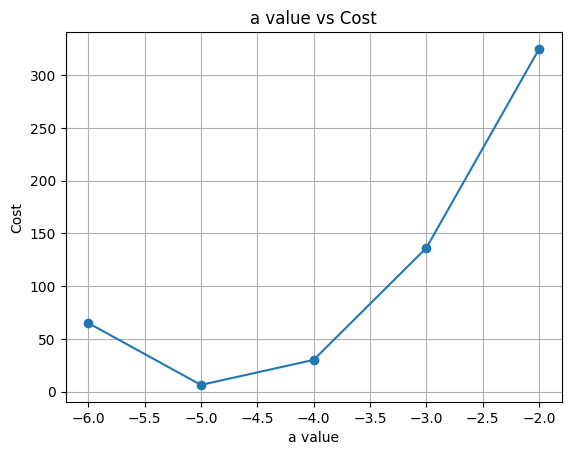

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(a_values, cost_values, marker='o')
plt.title('a value vs Cost')
plt.xlabel('a value')
plt.ylabel('Cost')
plt.grid(True)

In [16]:
learning_rate = 0.001
epochs = 1000

n = len(df)
cost_history = []

initial_a = a
initial_b = b

initial_cost = calculate_cost(a, b)
print(f'학습 전 Cost: {initial_cost:.4f}')

학습 전 Cost: 325.0000


In [17]:
for epoch in range(epochs):
    grad_a = 0
    grad_b = 0

    for i in range(len(df)):
        x = df.loc[i, 'temperature']
        y = df.loc[i, 'sales']

        pred = a * x + b
        pred_minus_actual = pred - y
        
        grad_a = grad_a + pred_minus_actual * x
        grad_b = grad_b + pred_minus_actual
    n = len(df)
    grad_a = grad_a / n
    grad_b = grad_b / n

    a = a - learning_rate * grad_a
    b = b - learning_rate * grad_b

    cost = calculate_cost(a, b)
    cost_history.append(cost)

    if epoch % 100 == 0:
        print(f"epoch={epoch}, Cost={cost:.4f}, a={a:.4f}, b={b:.4f}")

epoch=0, Cost=298.6928, a=-2.1150, b=79.9855
epoch=100, Cost=4.5747, a=-4.7092, b=79.6776
epoch=200, Cost=4.5072, a=-4.7480, b=79.6967
epoch=300, Cost=4.4965, a=-4.7515, b=79.7196
epoch=400, Cost=4.4865, a=-4.7543, b=79.7418
epoch=500, Cost=4.4771, a=-4.7571, b=79.7633
epoch=600, Cost=4.4683, a=-4.7598, b=79.7841
epoch=700, Cost=4.4601, a=-4.7623, b=79.8043
epoch=800, Cost=4.4523, a=-4.7648, b=79.8237
epoch=900, Cost=4.4451, a=-4.7673, b=79.8426


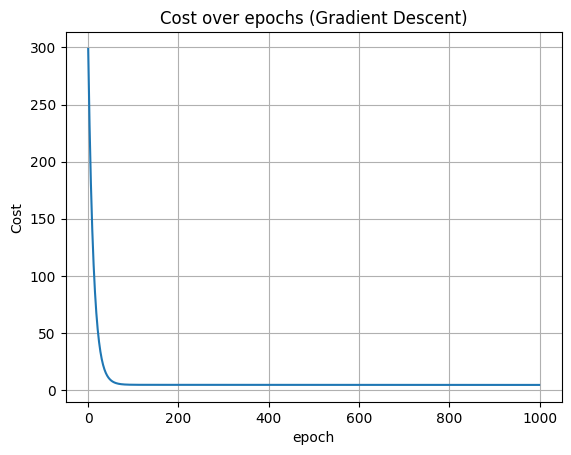

In [18]:
plt.figure()
plt.plot(range(len(cost_history)), cost_history)
plt.title('Cost over epochs (Gradient Descent)')
plt.xlabel('epoch')
plt.ylabel('Cost')
plt.grid(True)

In [19]:
final_a = a
final_b = b
final_cost = calculate_cost(final_a, final_b)

print('학습 전')
print(f'a = {initial_a:.4f}')
print(f'b = {initial_b:.4f}')
print(f'Cost = {initial_cost:.4f}')

print('학습 후')
print(f'a = {final_a:.4f}')
print(f'b = {final_b:.4f}')
print(f'Cost = {final_cost:.4f}')

학습 전
a = -2.0000
b = 80.0000
Cost = 325.0000
학습 후
a = -4.7696
b = 79.8607
Cost = 4.4384
